### Customer Analysis 

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from src.utils.paths import DATA_DIR_RAW, DATA_DIR_PROCESS

In [66]:
data = pd.read_csv(DATA_DIR_RAW / "Customers.csv")
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              2000 non-null   int64
 1   Gender                  2000 non-null   str  
 2   Age                     2000 non-null   int64
 3   Annual Income ($)       2000 non-null   int64
 4   Spending Score (1-100)  2000 non-null   int64
 5   Profession              1965 non-null   str  
 6   Work Experience         2000 non-null   int64
 7   Family Size             2000 non-null   int64
dtypes: int64(6), str(2)
memory usage: 151.2 KB


In [67]:
data=data.drop("CustomerID",axis=1)
data=data.rename(columns={'Annual Income ($)':'Annual Income' , 'Spending Score (1-100)':'Spending Score'})

data.describe()


,Age,Annual Income,Spending Score,Work Experience,Family Size
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,48.960000,110731.821500,50.962500,4.102500,3.768500
std,28.429747,45739.536688,27.934661,3.922204,1.970749
min,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25.000000,74572.000000,28.000000,1.000000,2.000000
50%,48.000000,110045.000000,50.000000,3.000000,4.000000
75%,73.000000,149092.750000,75.000000,7.000000,5.000000
max,99.000000,189974.000000,100.000000,17.000000,9.000000


In [68]:
data.head()

,Gender,Age,Annual Income,Spending Score,Profession,Work Experience,Family Size
0,Male,19,15000,39,Healthcare,1,4
1,Male,21,35000,81,Engineer,3,3
2,Female,20,86000,6,Engineer,1,1
3,Female,23,59000,77,Lawyer,0,2
4,Female,31,38000,40,Entertainment,2,6


### Types of Profession

In [69]:
data['Profession'].value_counts(dropna=False)


Profession
Artist           612
Healthcare       339
Entertainment    234
Engineer         179
Doctor           161
Executive        153
Lawyer           142
Marketing         85
Homemaker         60
NaN               35
Name: count, dtype: int64

### Gender Distrbution

In [70]:
data['Gender'].value_counts(dropna=False)


Gender
Female    1186
Male       814
Name: count, dtype: int64

## Visualizing 

### Income by profession  and spending score with income and profession

<Axes: xlabel='Annual Income', ylabel='Spending Score'>

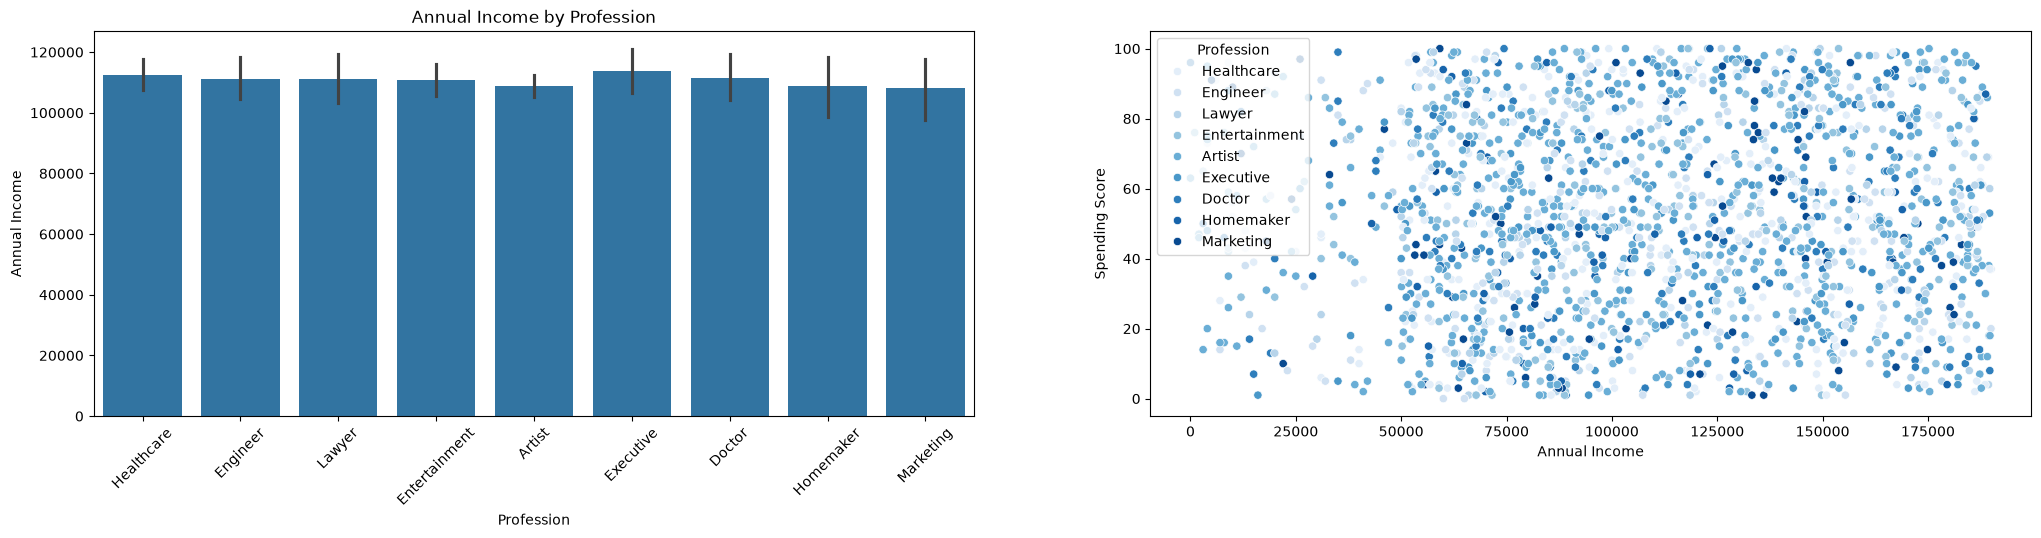

In [94]:
df_clean_prof = data.dropna(subset=["Profession"])

fig, axes = plt.subplots(1, 2, figsize=(25, 5))

sns.barplot(data=df_clean_prof, x="Profession", y="Annual Income" , ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_title("Annual Income by Profession")

sns.scatterplot(data=df_clean_prof,x='Annual Income',y='Spending Score',hue='Profession',ax=axes[1] ,palette='Blues')




### Looking spending score with family size  and income 

<Axes: xlabel='Annual Income', ylabel='Spending Score'>

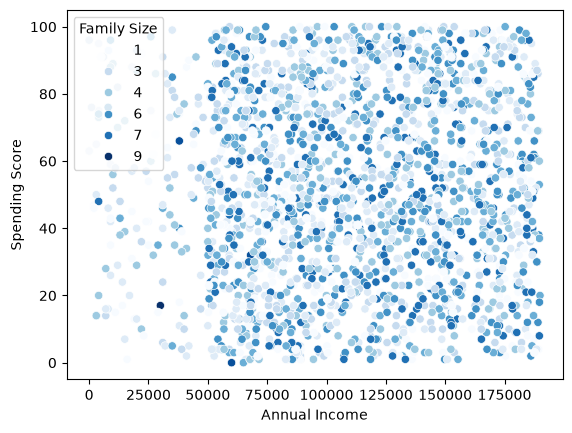

In [95]:
sns.scatterplot(data=data,x='Annual Income',y='Spending Score',hue='Family Size' ,palette ='Blues')

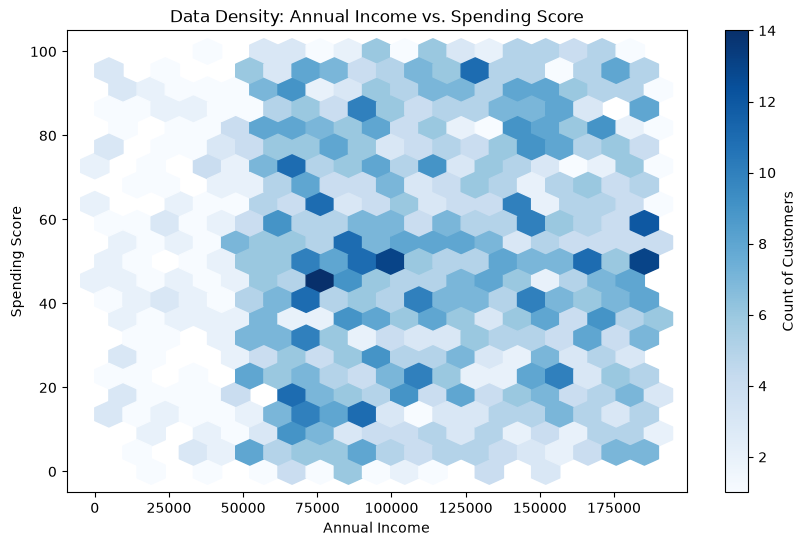

In [90]:
plt.figure(figsize=(10, 6))

plt.hexbin(data['Annual Income'], data['Spending Score'], gridsize=20, cmap='Blues', mincnt=1)
plt.colorbar(label='Count of Customers')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Data Density: Annual Income vs. Spending Score')
plt.show()

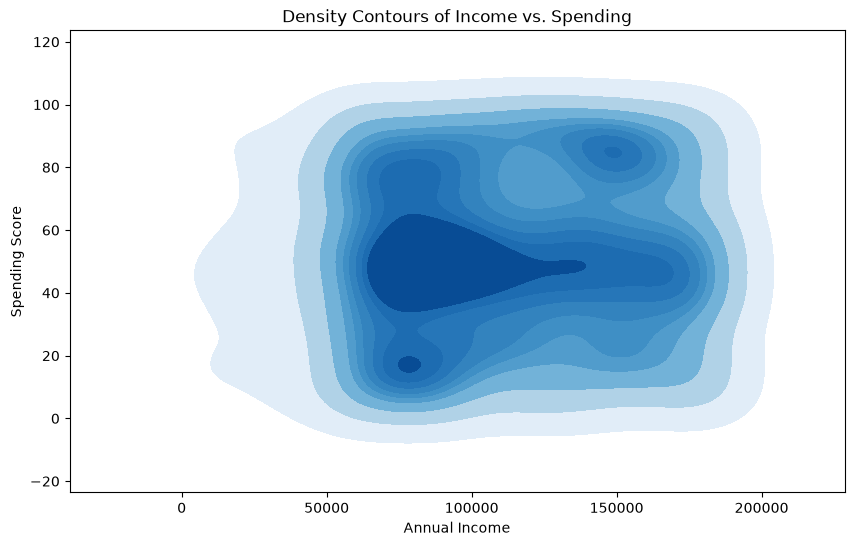

In [96]:
plt.figure(figsize=(10, 6))
sns.kdeplot(
    data=data, 
    x='Annual Income', 
    y='Spending Score', 
    cmap='Blues', 
    fill=True, 
    thresh=0.05, 
    levels=10
)
plt.title('Density Contours of Income vs. Spending')
plt.show()

## Observations

- No hidden patterns or cluster forming
- Data is distributed randomly 
- Income is almost same Independent of Income 
- Spending score is distributed from low to high index for all income ranges
- The data appears to be synthetically generated with a strict truncation/cutoff below $50,000 income, creating an artificial middle-class cluster in the center, while categorical variables like Profession and Family Size share no statistical relationship with the numerical data."
### Finally 
Data is not good for clusering
